Cell 1 — imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

from minicv.io import read_image
from minicv.color import rgb_to_gray
from minicv.utils import normalize, clip_pixels, pad, convolve2d

Cell 2 — image picker

In [5]:
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.png *.jpg *.jpeg")]
    )
    root.destroy()
    return path

IMAGE_PATH = pick_image()
img_rgb  = read_image(IMAGE_PATH, mode="rgb")
img_gray = read_image(IMAGE_PATH, mode="gray").astype(np.float64)
print(f"Image loaded: {img_rgb.shape}")

Image loaded: (588, 1400, 3)


Cell 3 — normalization modes

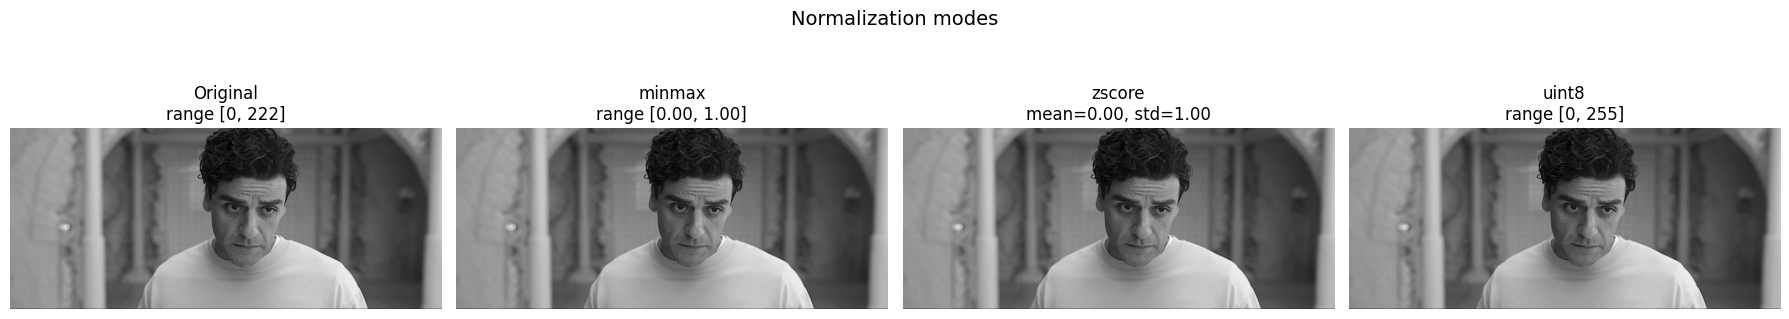

In [4]:
norm_minmax = normalize(img_gray, mode="minmax")
norm_zscore = normalize(img_gray, mode="zscore")
norm_uint8  = normalize(img_gray, mode="uint8")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title(f"Original\nrange [{img_gray.min():.0f}, {img_gray.max():.0f}]")
axes[0].axis("off")

axes[1].imshow(norm_minmax, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"minmax\nrange [{norm_minmax.min():.2f}, {norm_minmax.max():.2f}]")
axes[1].axis("off")

axes[2].imshow(norm_zscore, cmap="gray")
axes[2].set_title(f"zscore\nmean={norm_zscore.mean():.2f}, std={norm_zscore.std():.2f}")
axes[2].axis("off")

axes[3].imshow(norm_uint8, cmap="gray")
axes[3].set_title(f"uint8\nrange [{norm_uint8.min()}, {norm_uint8.max()}]")
axes[3].axis("off")

plt.suptitle("Normalization modes", fontsize=14)
plt.tight_layout()
plt.show()

Cell 4 — pixel clipping

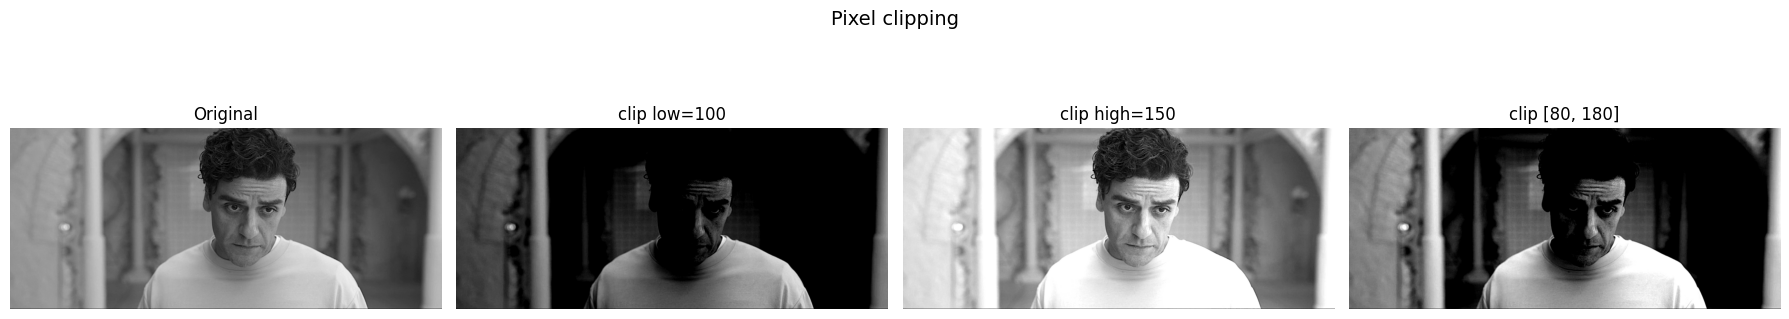

In [5]:
clipped_low  = clip_pixels(img_gray, low=100, high=255)
clipped_high = clip_pixels(img_gray, low=0,   high=150)
clipped_both = clip_pixels(img_gray, low=80,  high=180)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_gray,    cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(clipped_low, cmap="gray")
axes[1].set_title("clip low=100")
axes[1].axis("off")

axes[2].imshow(clipped_high, cmap="gray")
axes[2].set_title("clip high=150")
axes[2].axis("off")

axes[3].imshow(clipped_both, cmap="gray")
axes[3].set_title("clip [80, 180]")
axes[3].axis("off")

plt.suptitle("Pixel clipping", fontsize=14)
plt.tight_layout()
plt.show()

Cell 5 - Padding Mode

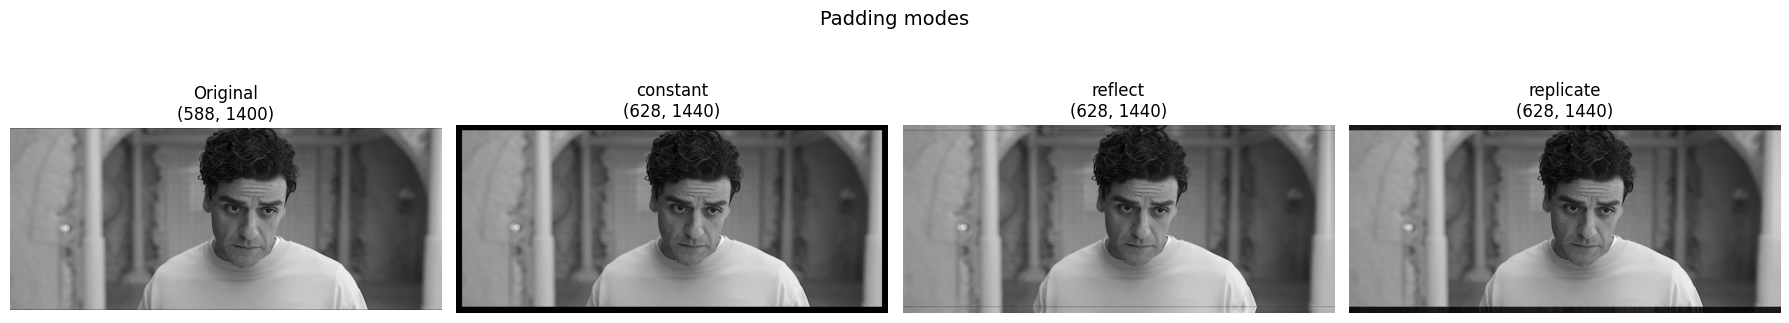

In [6]:
pad_constant  = pad(img_gray, pad_h=20, pad_w=20, mode="constant")
pad_reflect   = pad(img_gray, pad_h=20, pad_w=20, mode="reflect")
pad_replicate = pad(img_gray, pad_h=20, pad_w=20, mode="replicate")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_gray,      cmap="gray")
axes[0].set_title(f"Original\n{img_gray.shape}")
axes[0].axis("off")

axes[1].imshow(pad_constant,  cmap="gray")
axes[1].set_title(f"constant\n{pad_constant.shape}")
axes[1].axis("off")

axes[2].imshow(pad_reflect,   cmap="gray")
axes[2].set_title(f"reflect\n{pad_reflect.shape}")
axes[2].axis("off")

axes[3].imshow(pad_replicate, cmap="gray")
axes[3].set_title(f"replicate\n{pad_replicate.shape}")
axes[3].axis("off")

plt.suptitle("Padding modes", fontsize=14)
plt.tight_layout()
plt.show()

Cell 6 — 2D convolution with different kernels

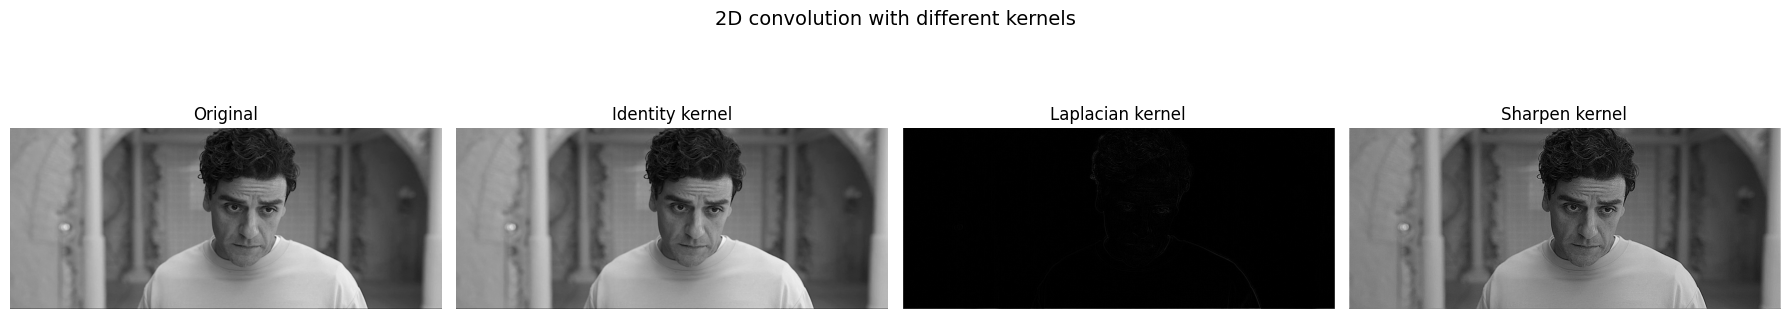

In [6]:
# Identity kernel — output should match input
kernel_identity = np.array([[0, 0, 0],
                             [0, 1, 0],
                             [0, 0, 0]], dtype=np.float64)

# Edge detection kernel (Laplacian)
kernel_laplacian = np.array([[ 0, -1,  0],
                              [-1,  4, -1],
                              [ 0, -1,  0]], dtype=np.float64)

# Sharpening kernel
kernel_sharpen = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]], dtype=np.float64)

out_identity  = convolve2d(img_gray, kernel_identity,  pad_mode="constant")
out_laplacian = convolve2d(img_gray, kernel_laplacian, pad_mode="constant")
out_sharpen   = convolve2d(img_gray, kernel_sharpen,   pad_mode="constant")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_gray,      cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(out_identity,  cmap="gray")
axes[1].set_title("Identity kernel")
axes[1].axis("off")

axes[2].imshow(np.clip(out_laplacian, 0, 255), cmap="gray")
axes[2].set_title("Laplacian kernel")
axes[2].axis("off")

axes[3].imshow(np.clip(out_sharpen, 0, 255),   cmap="gray")
axes[3].set_title("Sharpen kernel")
axes[3].axis("off")

plt.suptitle("2D convolution with different kernels", fontsize=14)
plt.tight_layout()
plt.show()

Cell 8 — padding mode comparison on convolution boundary

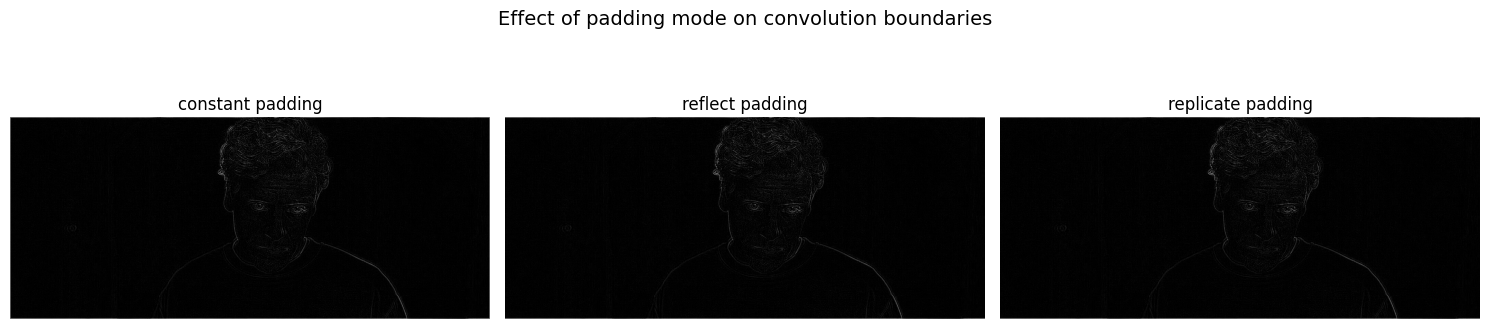

In [7]:
kernel_edge = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]], dtype=np.float64)

out_constant  = convolve2d(img_gray, kernel_edge, pad_mode="constant")
out_reflect   = convolve2d(img_gray, kernel_edge, pad_mode="reflect")
out_replicate = convolve2d(img_gray, kernel_edge, pad_mode="replicate")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, out, title in zip(axes,
    [out_constant, out_reflect, out_replicate],
    ["constant padding", "reflect padding", "replicate padding"]):
    ax.imshow(np.clip(out, 0, 255), cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Effect of padding mode on convolution boundaries", fontsize=14)
plt.tight_layout()
plt.show()